In [1]:
import sys
sys.path.append('..')

import glob
import numpy as np
import torch
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, f1_score

from src.models import RobustDetector
from src.utils import get_freqs, get_freqs_mask

In [9]:
CKPT_PATH = "../checkpoints/sonics/robustdetector-sonics-log_stft-use_conv-lamb=0.5.ckpt"
DATA_DIR  = "../data/sonics/attack/test/discrete"
SEED      = 42

In [7]:
torch.manual_seed(SEED)
np.random.seed(SEED)

model = RobustDetector.load_from_checkpoint(CKPT_PATH)
model.eval()
device = torch.device('cpu')
model = model.to(device)

mode = model.transform_type if not model.log_stft else 'stft'
print(f"Model loaded | transform={model.transform_type} | log_stft={model.log_stft} | use_conv={model.use_convolution}")

Model loaded | transform=stft | log_stft=True | use_conv=True


In [8]:
# Load all fakeprints and balance 50/50
def load_class(data_dir, label, model):
    freqs = get_freqs(n_fft=model.n_fft, sr=model.sampling_rate,
                      log=(model.transform_type == 'cqt'),
                      bins_per_octave=model.bins_per_octave)
    mask = get_freqs_mask(freqs, model.sampling_rate, model.freq_range)

    fps, speed_factors = [], []
    subdir = 'ai' if label == 1 else 'human'
    for path in sorted(glob.glob(f"{data_dir}/{subdir}/*.npz")):
        d = np.load(path)
        fp = d[model.transform_type]  # (N, n_bins)
        fp = fp[:, mask]
        sf = d.get('speed_factors', np.ones(len(fp)))
        valid = ~(np.isnan(fp).any(axis=1) | np.isinf(fp).any(axis=1))
        fps.append(fp[valid])
        speed_factors.append(sf[valid])
    concat_sf = np.concatenate(speed_factors)
    print(f"[{subdir}] Number of different speed factors: {len(np.unique(concat_sf))}")
    return np.concatenate(fps), concat_sf

ai_fp, ai_sf   = load_class(DATA_DIR, 1, model)
hu_fp, hu_sf   = load_class(DATA_DIR, 0, model)

print(f"Speed factor range : {min(hu_sf)}, {max(hu_sf)}")

# Balance
n = min(len(ai_fp), len(hu_fp))
rng = np.random.default_rng(SEED)
ai_idx = rng.choice(len(ai_fp), n, replace=False)
hu_idx = rng.choice(len(hu_fp), n, replace=False)

fps    = np.concatenate([ai_fp[ai_idx], hu_fp[hu_idx]])
labels = np.array([1]*n + [0]*n)
sfs    = np.concatenate([ai_sf[ai_idx], hu_sf[hu_idx]])

print(f"Balanced test set: {n} AI + {n} Human = {2*n} total")

[ai] Number of different speed factors: 198
[human] Number of different speed factors: 2572
Speed factor range : 0.701095573634031, 1.3998023713002912
Balanced test set: 1821 AI + 1821 Human = 3642 total


In [10]:
# Run inference
with torch.inference_mode():
    x = torch.from_numpy(fps).float().to(device)
    if model.log_stft:
        x = model.stft_to_log(x)
    logits, _ = model(x, convolve=model.use_convolution)
    probs = torch.sigmoid(logits).squeeze(-1).cpu().numpy()

print(f"Probs range: [{probs.min():.3f}, {probs.max():.3f}]")

Probs range: [0.000, 1.000]


/Users/thomas/projects/robust-deepfake-detector/scripts/../src/models/linear.py:31: UserWarning: Using padding='same' with even kernel lengths and odd dilation may require a zero-padded copy of the input be created (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/native/Convolution.cpp:1041.)
  cross_corr = F.conv1d(x_conv, w_conv, padding="same").squeeze(1) # (B, 1, F) x (1, 1, F) -> (B, F)


In [11]:
# Optimal threshold via F1
thresholds = np.linspace(0, 1, 201)
f1_scores = [f1_score(labels, probs >= t, zero_division=0) for t in thresholds]
best_t = thresholds[np.argmax(f1_scores)]
best_f1 = max(f1_scores)
print(f"Optimal threshold: {best_t:.3f}  |  Best F1: {best_f1:.4f}")

Optimal threshold: 0.390  |  Best F1: 0.9714


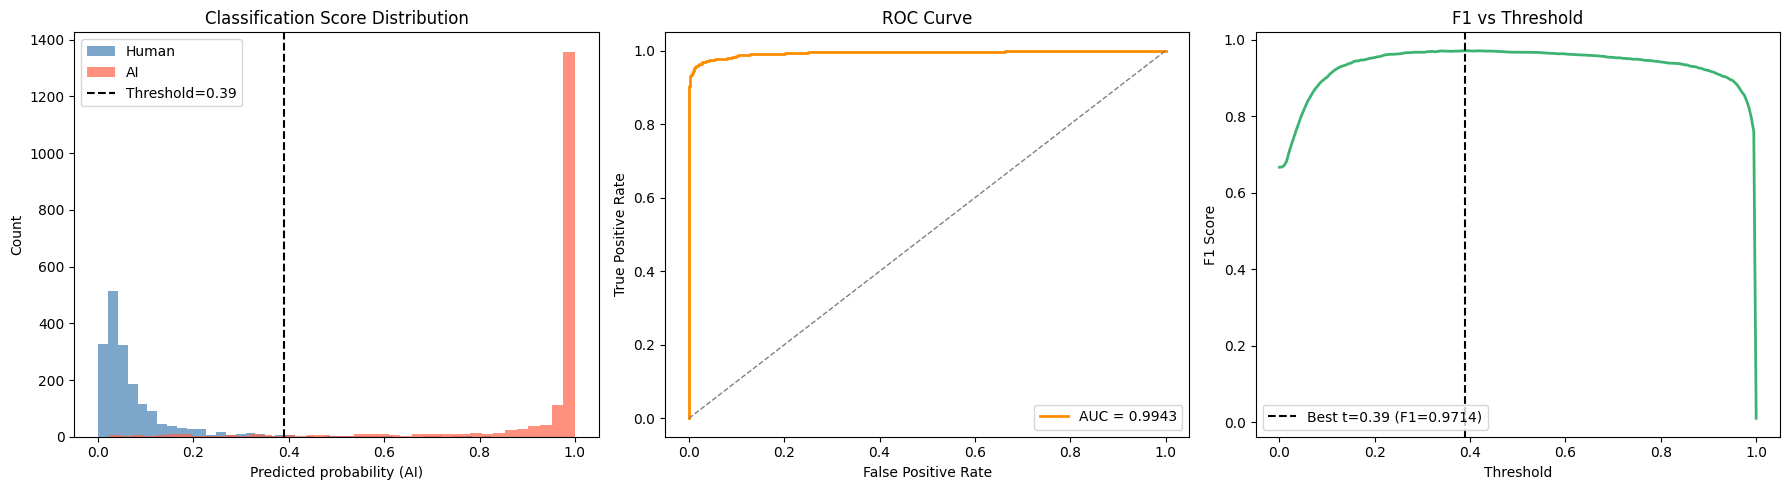

In [12]:
fpr, tpr, _ = roc_curve(labels, probs)
roc_auc = auc(fpr, tpr)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- 1. Classification histogram ---
ax = axes[0]
ax.hist(probs[labels == 0], bins=40, alpha=0.7, label='Human', color='steelblue')
ax.hist(probs[labels == 1], bins=40, alpha=0.7, label='AI',    color='tomato')
ax.axvline(best_t, color='black', linestyle='--', linewidth=1.5, label=f'Threshold={best_t:.2f}')
ax.set_xlabel('Predicted probability (AI)')
ax.set_ylabel('Count')
ax.set_title('Classification Score Distribution')
ax.legend()

# --- 2. ROC / AUC ---
ax = axes[1]
ax.plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {roc_auc:.4f}')
ax.plot([0, 1], [0, 1], color='grey', linestyle='--', lw=1)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve')
ax.legend()

# --- 3. F1 vs Threshold ---
ax = axes[2]
ax.plot(thresholds, f1_scores, color='mediumseagreen', lw=2)
ax.axvline(best_t, color='black', linestyle='--', linewidth=1.5, label=f'Best t={best_t:.2f} (F1={best_f1:.4f})')
ax.set_xlabel('Threshold')
ax.set_ylabel('F1 Score')
ax.set_title('F1 vs Threshold')
ax.legend()

plt.tight_layout()
plt.show()

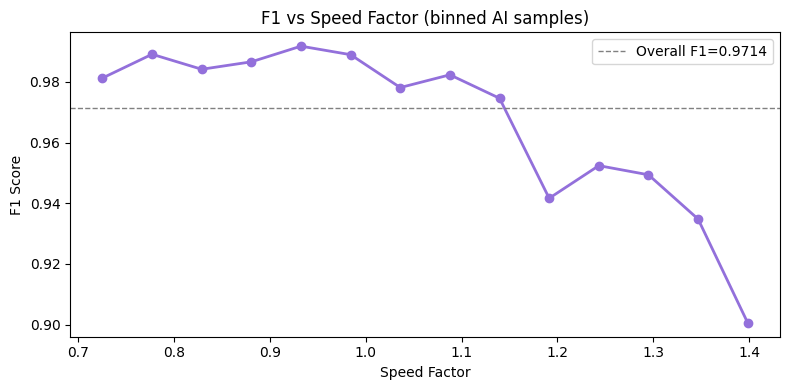

In [13]:
# F1 vs Speed Factor (AI samples only)
ai_probs = probs[:n]   # first n are AI
ai_sfs   = sfs[:n]
ai_labels = labels[:n]

# Bin by speed factor
bins = np.linspace(ai_sfs.min(), ai_sfs.max(), 15)
bin_centers, bin_f1s = [], []
for i in range(len(bins) - 1):
    mask_b = (ai_sfs >= bins[i]) & (ai_sfs < bins[i+1])
    if mask_b.sum() < 5:
        continue
    # AI vs full-human at this bin
    p_bin = np.concatenate([ai_probs[mask_b], probs[n:][~mask_b][:mask_b.sum()]])
    l_bin = np.array([1]*mask_b.sum() + [0]*mask_b.sum())
    f1_b = f1_score(l_bin, p_bin >= best_t, zero_division=0)
    bin_centers.append((bins[i] + bins[i+1]) / 2)
    bin_f1s.append(f1_b)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(bin_centers, bin_f1s, marker='o', color='mediumpurple', lw=2)
ax.axhline(best_f1, color='grey', linestyle='--', lw=1, label=f'Overall F1={best_f1:.4f}')
ax.set_xlabel('Speed Factor')
ax.set_ylabel('F1 Score')
ax.set_title('F1 vs Speed Factor (binned AI samples)')
ax.legend()
plt.tight_layout()
plt.show()